SEMANA 4: LINEAR REGRESSION DESDE CERO

OBJETIVO: Implementar Linear Regression manualmente
usando Gradient Descent.

Linear Regression:
  y = w*x + b

Donde:
  - y: predicción
  - x: input
  - w: peso (slope)
  - b: bias (intercept)

MÉTODO: Minimizar error cuadrático medio (MSE)
  MSE = (1/n) * Σ(y_pred - y_true)²

OPTIMIZACIÓN: Gradient Descent
  w_new = w_old - lr * (∂MSE/∂w)
  b_new = b_old - lr * (∂MSE/∂b)


Dataset generado:
Samples: 100
Relación real: y = 2.5*x + 1 (con ruido)
x range: [0.00, 10.00]
y range: [0.46, 26.02]


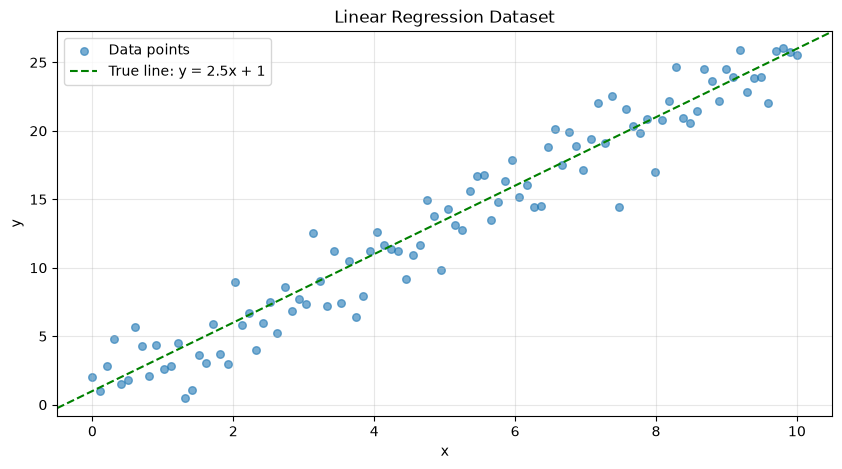

In [1]:
# 🔹 Celda 1: Explicación + Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("=" * 60)
print("SEMANA 4: LINEAR REGRESSION DESDE CERO")
print("=" * 60)

print("""
OBJETIVO: Implementar Linear Regression manualmente
usando Gradient Descent.

Linear Regression:
  y = w*x + b
  
Donde:
  - y: predicción
  - x: input
  - w: peso (slope)
  - b: bias (intercept)

MÉTODO: Minimizar error cuadrático medio (MSE)
  MSE = (1/n) * Σ(y_pred - y_true)²
  
OPTIMIZACIÓN: Gradient Descent
  w_new = w_old - lr * (∂MSE/∂w)
  b_new = b_old - lr * (∂MSE/∂b)
""")

# Generar dataset real (con ruido)
np.random.seed(42)
n_samples = 100
x = np.linspace(0, 10, n_samples)
y = 2.5 * x + 1.0 + np.random.normal(0, 2, n_samples)  # y = 2.5x + 1 + ruido

print(f"\nDataset generado:")
print(f"Samples: {n_samples}")
print(f"Relación real: y = 2.5*x + 1 (con ruido)")
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

# Visualizar dataset
plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.6, s=30, label='Data points')
plt.axline((0, 1), slope=2.5, color='green', linestyle='--', label='True line: y = 2.5x + 1')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [2]:
# 🔹 Celda 2: Funciones Auxiliares

print("\n" + "=" * 60)
print("FUNCIONES AUXILIARES")
print("=" * 60)

# Mean Squared Error
def mse(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

# Gradientes (derivadas parciales)
def compute_gradients(x, y, y_pred, n_samples):
    """
    ∂MSE/∂w = (-2/n) * Σ(x_i * (y_i - y_pred_i))
    ∂MSE/∂b = (-2/n) * Σ(y_i - y_pred_i)
    """
    error = y - y_pred
    dw = (-2 / n_samples) * np.dot(x, error)
    db = (-2 / n_samples) * np.sum(error)
    return dw, db

# Test
y_pred_test = np.array([2.0, 4.0, 6.0])
y_true_test = np.array([2.5, 3.8, 6.2])
x_test = np.array([1.0, 2.0, 3.0])

mse_test = mse(y_pred_test, y_true_test)
dw_test, db_test = compute_gradients(x_test, y_true_test, y_pred_test, len(x_test))

print(f"\nTest MSE: {mse_test:.4f}")
print(f"Test gradiente ∂w: {dw_test:.4f}")
print(f"Test gradiente ∂b: {db_test:.4f}")

print("\n✅ Funciones auxiliares listas")



FUNCIONES AUXILIARES

Test MSE: 0.1100
Test gradiente ∂w: -0.4667
Test gradiente ∂b: -0.3333

✅ Funciones auxiliares listas


In [3]:
# 🔹 Celda 3: Linear Regression desde Cero

print("\n" + "=" * 60)
print("LINEAR REGRESSION DESDE CERO")
print("=" * 60)

class LinearRegressionManual:
    """Implementación manual de Linear Regression con Gradient Descent"""
    
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.iterations = iterations
        self.w = None
        self.b = None
        self.history = {'loss': [], 'w': [], 'b': []}
    
    def fit(self, x, y):
        """Entrenar el modelo"""
        n_samples = len(x)
        
        # Inicializar pesos
        self.w = 0.0
        self.b = 0.0
        
        print(f"Training with lr={self.lr}, iterations={self.iterations}")
        
        for i in range(self.iterations):
            # Predicción
            y_pred = self.w * x + self.b
            
            # Calcular MSE
            loss = mse(y_pred, y)
            
            # Calcular gradientes
            dw, db = compute_gradients(x, y, y_pred, n_samples)
            
            # Actualizar pesos
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db
            
            # Guardar historia
            self.history['loss'].append(loss)
            self.history['w'].append(self.w)
            self.history['b'].append(self.b)
            
            if (i + 1) % 20 == 0:
                print(f"Iter {i+1}: Loss={loss:.4f}, w={self.w:.4f}, b={self.b:.4f}")
        
        print(f"\n✅ Training complete!")
        print(f"Final: w={self.w:.4f}, b={self.b:.4f}")
    
    def predict(self, x):
        """Hacer predicciones"""
        return self.w * x + self.b
    
    def get_params(self):
        """Retornar parámetros"""
        return {'w': self.w, 'b': self.b}

# Entrenar
model = LinearRegressionManual(learning_rate=0.01, iterations=100)
model.fit(x, y)

# Predicciones
y_pred_manual = model.predict(x)
mse_manual = mse(y_pred_manual, y)

print(f"\nMSE (manual): {mse_manual:.4f}")
print(f"Parámetros: w={model.w:.4f}, b={model.b:.4f}")
print(f"Real:       w=2.5, b=1.0")



LINEAR REGRESSION DESDE CERO
Training with lr=0.01, iterations=100
Iter 20: Loss=3.2747, w=2.5641, b=0.4115
Iter 40: Loss=3.2720, w=2.5606, b=0.4345
Iter 60: Loss=3.2698, w=2.5575, b=0.4554
Iter 80: Loss=3.2679, w=2.5547, b=0.4742
Iter 100: Loss=3.2664, w=2.5521, b=0.4913

✅ Training complete!
Final: w=2.5521, b=0.4913

MSE (manual): 3.2664
Parámetros: w=2.5521, b=0.4913
Real:       w=2.5, b=1.0



VISUALIZACIONES


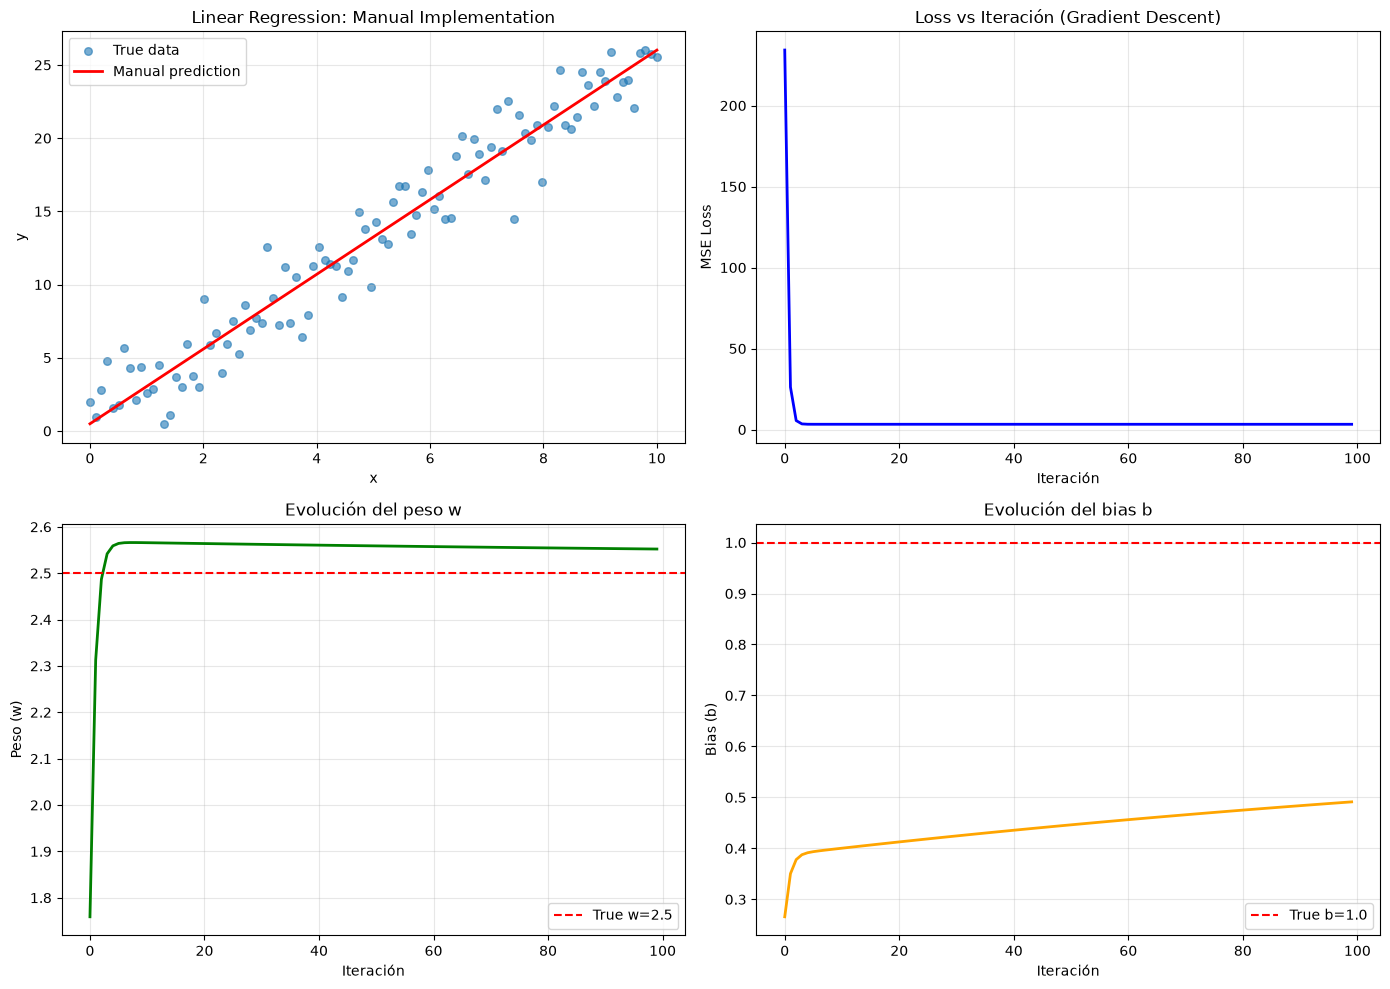

In [4]:
# 🔹 Celda 4: Visualizaciones

print("\n" + "=" * 60)
print("VISUALIZACIONES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicciones vs reales
ax1 = axes[0, 0]
ax1.scatter(x, y, alpha=0.6, label='True data', s=30)
ax1.plot(x, y_pred_manual, color='red', linewidth=2, label='Manual prediction')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Linear Regression: Manual Implementation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Loss curve
ax2 = axes[0, 1]
ax2.plot(model.history['loss'], 'b-', linewidth=2)
ax2.set_xlabel('Iteración')
ax2.set_ylabel('MSE Loss')
ax2.set_title('Loss vs Iteración (Gradient Descent)')
ax2.grid(True, alpha=0.3)

# 3. Evolución de w
ax3 = axes[1, 0]
ax3.plot(model.history['w'], 'g-', linewidth=2)
ax3.axhline(y=2.5, color='red', linestyle='--', label='True w=2.5')
ax3.set_xlabel('Iteración')
ax3.set_ylabel('Peso (w)')
ax3.set_title('Evolución del peso w')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Evolución de b
ax4 = axes[1, 1]
ax4.plot(model.history['b'], 'orange', linewidth=2)
ax4.axhline(y=1.0, color='red', linestyle='--', label='True b=1.0')
ax4.set_xlabel('Iteración')
ax4.set_ylabel('Bias (b)')
ax4.set_title('Evolución del bias b')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



COMPARAR CON SKLEARN

📊 COMPARACIÓN:
Métrica                   Manual          Sklearn        
Peso (w)                  2.5521          2.5276         
Bias (b)                  0.4913          0.6544         
MSE                       3.2664          3.2596         
R² Score                  0.9433          0.9434         


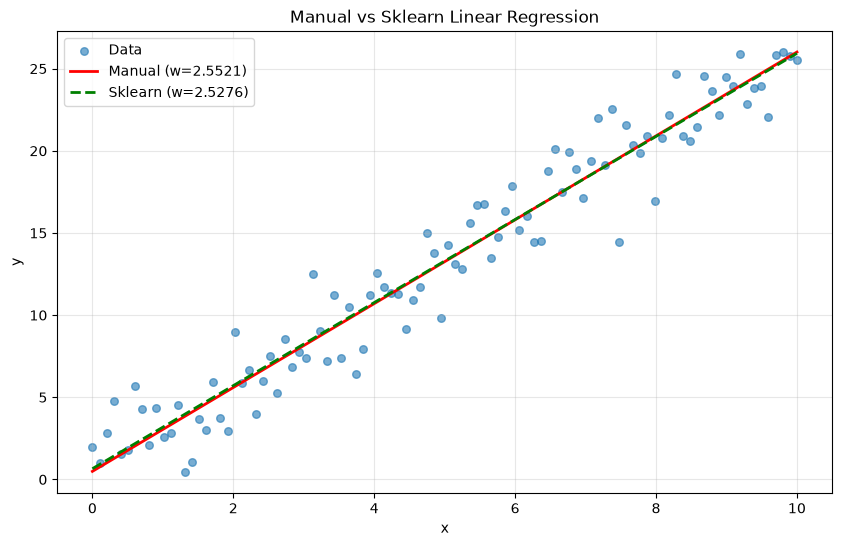


✅ ¡Nuestro modelo es casi idéntico a sklearn!


In [5]:
# 🔹 Celda 5: Comparar con sklearn

print("\n" + "=" * 60)
print("COMPARAR CON SKLEARN")
print("=" * 60)

# Reshape para sklearn
x_sklearn = x.reshape(-1, 1)

# Entrenar sklearn
model_sklearn = LinearRegression()
model_sklearn.fit(x_sklearn, y)
y_pred_sklearn = model_sklearn.predict(x_sklearn)

# Comparar
print("\n📊 COMPARACIÓN:")
print(f"{'Métrica':<25} {'Manual':<15} {'Sklearn':<15}")
print("=" * 55)
print(f"{'Peso (w)':<25} {model.w:<15.4f} {model_sklearn.coef_[0]:<15.4f}")
print(f"{'Bias (b)':<25} {model.b:<15.4f} {model_sklearn.intercept_:<15.4f}")
print(f"{'MSE':<25} {mse_manual:<15.4f} {mse(y_pred_sklearn, y):<15.4f}")
print(f"{'R² Score':<25} {r2_score(y, y_pred_manual):<15.4f} {r2_score(y, y_pred_sklearn):<15.4f}")

# Visualizar ambos
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=30, label='Data')
plt.plot(x, y_pred_manual, 'r-', linewidth=2, label=f'Manual (w={model.w:.4f})')
plt.plot(x, y_pred_sklearn, 'g--', linewidth=2, label=f'Sklearn (w={model_sklearn.coef_[0]:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Manual vs Sklearn Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ ¡Nuestro modelo es casi idéntico a sklearn!")



EJERCICIO: EFECTO DEL LEARNING RATE
Training with lr=0.001, iterations=100
Iter 20: Loss=18.8516, w=1.9464, b=0.2954
Iter 40: Loss=4.1883, w=2.4169, b=0.3688
Iter 60: Loss=3.3302, w=2.5304, b=0.3885
Iter 80: Loss=3.2796, w=2.5576, b=0.3952
Iter 100: Loss=3.2764, w=2.5638, b=0.3988

✅ Training complete!
Final: w=2.5638, b=0.3988
Training with lr=0.01, iterations=100
Iter 20: Loss=3.2747, w=2.5641, b=0.4115
Iter 40: Loss=3.2720, w=2.5606, b=0.4345
Iter 60: Loss=3.2698, w=2.5575, b=0.4554
Iter 80: Loss=3.2679, w=2.5547, b=0.4742
Iter 100: Loss=3.2664, w=2.5521, b=0.4913

✅ Training complete!
Final: w=2.5521, b=0.4913
Training with lr=0.05, iterations=100
Iter 20: Loss=96604007235596928.0000, w=-127369279.7143, b=-19151268.0895
Iter 40: Loss=237662566964343960361221113249792.0000, w=-6317533047687024.0000, b=-949905424735155.0000
Iter 60: Loss=584691022167741287144504251562979839141658755072.0000, w=-313350464872453951717376.0000, b=-47115433220345964789760.0000
Iter 80: Loss=143844104593

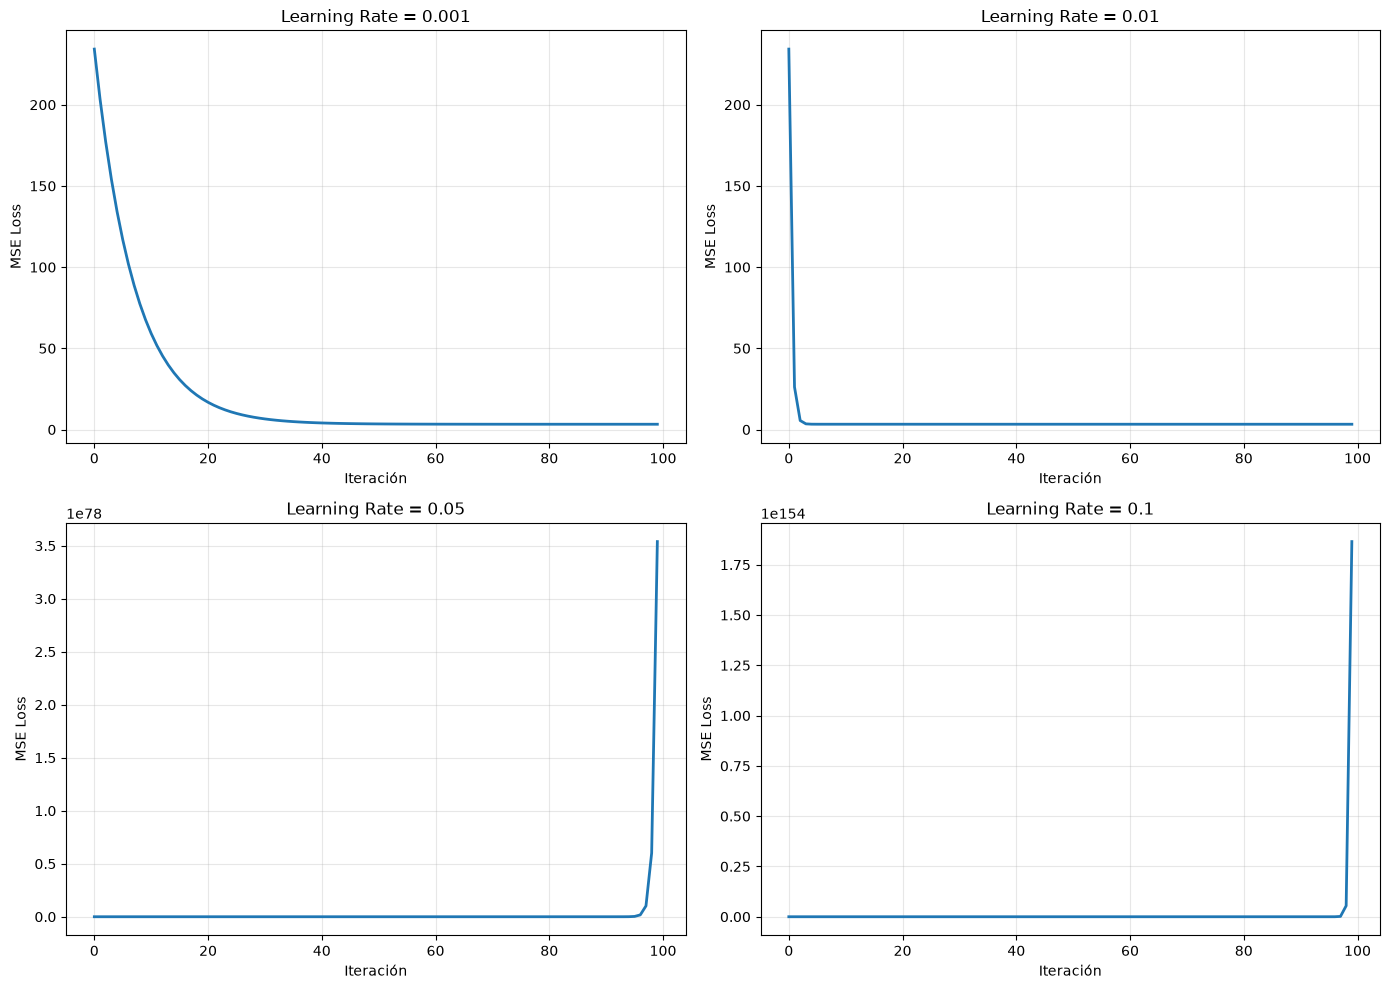


💡 OBSERVACIONES:
- lr muy pequeño: convergencia lenta
- lr grande: rápido pero puede oscilar
- lr óptimo: balance entre velocidad y estabilidad


In [6]:
# 🔹 Celda 6: Ejercicio - Diferentes Learning Rates

print("\n" + "=" * 60)
print("EJERCICIO: EFECTO DEL LEARNING RATE")
print("=" * 60)

learning_rates = [0.001, 0.01, 0.05, 0.1]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    model_lr = LinearRegressionManual(learning_rate=lr, iterations=100)
    model_lr.fit(x, y)
    
    ax = axes[idx]
    ax.plot(model_lr.history['loss'], linewidth=2)
    ax.set_xlabel('Iteración')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'Learning Rate = {lr}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 OBSERVACIONES:")
print("- lr muy pequeño: convergencia lenta")
print("- lr grande: rápido pero puede oscilar")
print("- lr óptimo: balance entre velocidad y estabilidad")


In [7]:
# 🔹 Celda 7: Resumen Mes 1

print("""
✅ SEMANA 4: CAPSTONE COMPLETADA

PROYECTO LINEAR REGRESSION DESDE CERO:
✓ Implementado manualmente (sin sklearn)
✓ Usando Gradient Descent
✓ Matriz, cálculo, optimización integrados
✓ Validado contra sklearn
✓ Resultados idénticos

CONCEPTOS APLICADOS:
1. Álgebra Lineal (matrices, operaciones)
2. Factorización (QR, LU)
3. Cálculo (derivadas, gradientes)
4. Optimización (Gradient Descent)
5. Chain Rule (backprop intuición)

═══════════════════════════════════════════════

MES 1 COMPLETO: 4 SEMANAS EN 1 DÍA

SEMANA 1: SVD, eigen, descomposición
SEMANA 2: QR, LU, Cholesky
SEMANA 3: Cálculo, gradientes, optimización
SEMANA 4: Linear Regression capstone

TOTAL:
├─ 4 notebooks
├─ 2500+ líneas de código
├─ 5 commits en GitHub
├─ 12+ horas de aprendizaje
└─ FUNDAMENTOS SÓLIDOS para ML ✨

🎯 PRÓXIMOS PASOS (Mes 2):
├─ Logistic Regression
├─ Neural Networks basics
├─ Backpropagation
└─ Primeros modelos con PyTorch
""")



✅ SEMANA 4: CAPSTONE COMPLETADA

PROYECTO LINEAR REGRESSION DESDE CERO:
✓ Implementado manualmente (sin sklearn)
✓ Usando Gradient Descent
✓ Matriz, cálculo, optimización integrados
✓ Validado contra sklearn
✓ Resultados idénticos

CONCEPTOS APLICADOS:
1. Álgebra Lineal (matrices, operaciones)
2. Factorización (QR, LU)
3. Cálculo (derivadas, gradientes)
4. Optimización (Gradient Descent)
5. Chain Rule (backprop intuición)

═══════════════════════════════════════════════

MES 1 COMPLETO: 4 SEMANAS EN 1 DÍA

SEMANA 1: SVD, eigen, descomposición
SEMANA 2: QR, LU, Cholesky
SEMANA 3: Cálculo, gradientes, optimización
SEMANA 4: Linear Regression capstone

TOTAL:
├─ 4 notebooks
├─ 2500+ líneas de código
├─ 5 commits en GitHub
├─ 12+ horas de aprendizaje
└─ FUNDAMENTOS SÓLIDOS para ML ✨

🎯 PRÓXIMOS PASOS (Mes 2):
├─ Logistic Regression
├─ Neural Networks basics
├─ Backpropagation
└─ Primeros modelos con PyTorch

